In [1]:
import os 
from functools import singledispatch
from collections.abc import Sequence, Sized, Iterable
from datetime import datetime
from typing import Optional, Union, List, Any, Generic
import pickle

import numpy as np
from numpy import typing as npt
from sklearn.model_selection import train_test_split

import pyarrow as pa
from pyarrow import compute as pc 
from torch.utils.data import DataLoader, SubsetRandomSampler, SequentialSampler

import torch
from torchmetrics import MetricCollection
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAccuracy

from torchmodel import archs
from torchmodel.torchmodel import TensorDictModel
from torchmodel.callbacks import EarlyStopping
from torchmodel.datasets import JetDataset, batch_collate

In [2]:
def get_model(dnn_layers, in_keys, out_key, device=torch.device("cpu"), name="", do_debug=False, learning_rate=0.01, sched_patience=5):
    classifier = TensorDictModel(
        archs.DNN(dnn_layers, dropout_prob=0.2, do_batch_norm=True), in_keys, out_key, device=device, name=name, do_debug=do_debug
    )
    optimizer = torch.optim.Adam(classifier().parameters(), lr=learning_rate)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=sched_patience
    )
    classifier.compile(
        criterion=torch.nn.BCEWithLogitsLoss(reduction="none"),
        optimizer=optimizer,
        compile_mode="default",
        scheduler=lr_scheduler,
    )

    return classifier

def add_constit_slice_column(jet_table, consit_col_name, new_col_name, start, stop=None):
    if stop is None:
        stop = start+1
    carr = pc.list_slice(jet_table[consit_col_name], start, stop=stop).combine_chunks().flatten()
    return jet_table.append_column(new_col_name, carr)

def add_leading_constit_column(jet_table): 
    constit_pt_arr = jet_table["constit_pt"].combine_chunks().values
    constit_jet_indices = jet_table["constit_pt"].combine_chunks().value_parent_indices()
    constit_table = pa.table({"constit_pt":constit_pt_arr, "jet_index":constit_jet_indices})
    agg = constit_table.group_by("jet_index").aggregate([("constit_pt", "max")])

    return jet_table.append_column("leading_constit_pt", agg["constit_pt_max"])

def pa_table(source : str , label : Optional[npt.ArrayLike] = None):
    buffer = pa.memory_map(source, "rb")
    table = pa.ipc.open_file(buffer).read_all()
    _len = len(table)
    label_arr = None
    if isinstance(label, (int, np.number)):
        label_arr = np.full(_len, label, dtype=np.int_)
    elif isinstance(label, np.ndarray):
        assert len(label) == _len
        label_arr = np.asarray(label, dtype=np.int_)
    else: 
        label_arr = np.empty(0)

    return buffer, add_extra_columns(table), label_arr

def pa_concated_table(source : Sequence[str], label : Optional[Sequence[npt.ArrayLike]] = None):
    n_tables = len(source)
    label_iter = label if label is not None else [None]*n_tables
    assert len(label) == n_tables
    buffer_list = []
    table_list = []
    label_list = []
    for _source, _label in zip(source, label_iter):
        if not isinstance(_source, str):
            raise TypeError("Can't use sources other than path strings for pa.Table!")
        buffer, table, label_arr = pa_table(_source, label=_label)
        buffer_list.append(buffer)
        table_list.append(table)
        label_list.append(label_arr)

    return buffer_list, pa.concat_tables(table_list), np.concatenate(label_list)

def add_extra_columns(table : pa.Table) -> pa.Table:
    table = add_constit_slice_column(table, "constit_pt", "leading_constit_pt", 0)
    table = add_constit_slice_column(table, "constit_eta", "leading_constit_eta", 0)
    table = add_constit_slice_column(table, "constit_phi", "leading_constit_phi", 0)

    table = add_constit_slice_column(table, "constit_pt", "subleading_constit_pt", 1)
    table = add_constit_slice_column(table, "constit_eta", "subleading_constit_eta", 1)
    table = add_constit_slice_column(table, "constit_phi", "subleading_constit_phi", 1)

    return table


In [3]:
 
 emb_data_folder = "outputs/30May25-1147"
 pth_bins = ["11", "15", "20", "25", "35", "45", "55", "infty"]
 pth_bin_folders = [f"{emb_data_folder}/ptHat{pth_low}to{pth_high}" for pth_low, pth_high in zip(pth_bins[:-1], pth_bins[1:])]
 n_pth_bins = len(pth_bin_folders)
 pth_label = list(range(1, n_pth_bins+1))
 print(len(pth_label), n_pth_bins)

 gen_match_buffers, gen_match_table, gen_match_stratify_label = pa_concated_table([f"{folder}/gen-matches.arrow" for folder in pth_bin_folders], label=pth_label)
 gen_miss_buffers, gen_miss_table, gen_miss_stratify_label = pa_concated_table([f"{folder}/misses.arrow" for folder in pth_bin_folders], label=pth_label) 
 reco_match_buffers, reco_match_table, reco_match_stratify_label = pa_concated_table([f"{folder}/reco-matches.arrow" for folder in pth_bin_folders], label=pth_label)
 reco_fake_buffers, reco_fake_table, reco_fake_stratify_label = pa_concated_table([f"{folder}/fakes.arrow" for folder in pth_bin_folders], label=pth_label)

 data_buffer, data_table, data_stratify_label = pa_table("outputs/jets-conPtMin0.2.arrow", label=0)

 n_data = len(data_table)

 n_gen_matches = len(gen_match_table)
 n_gen_misses = len(gen_miss_table)
 n_reco_matches = len(reco_match_table)
 n_reco_fakes = len(reco_fake_table)

 assert n_gen_matches == n_reco_matches

 n_matches = n_gen_matches 
 n_gen = n_matches + n_gen_misses
 n_reco = n_matches + n_reco_fakes

 print("Number of matched gen jets, matched reco jets:", n_gen_matches, n_reco_matches, n_matches)
 print("Number of missed gen jets, fake reco jets:", n_gen_misses, n_reco_fakes)
 print("Number of data jets:", n_data)


7 7


Number of matched gen jets, matched reco jets: 2862964 2862964 2862964
Number of missed gen jets, fake reco jets: 11985390 79281
Number of data jets: 866655


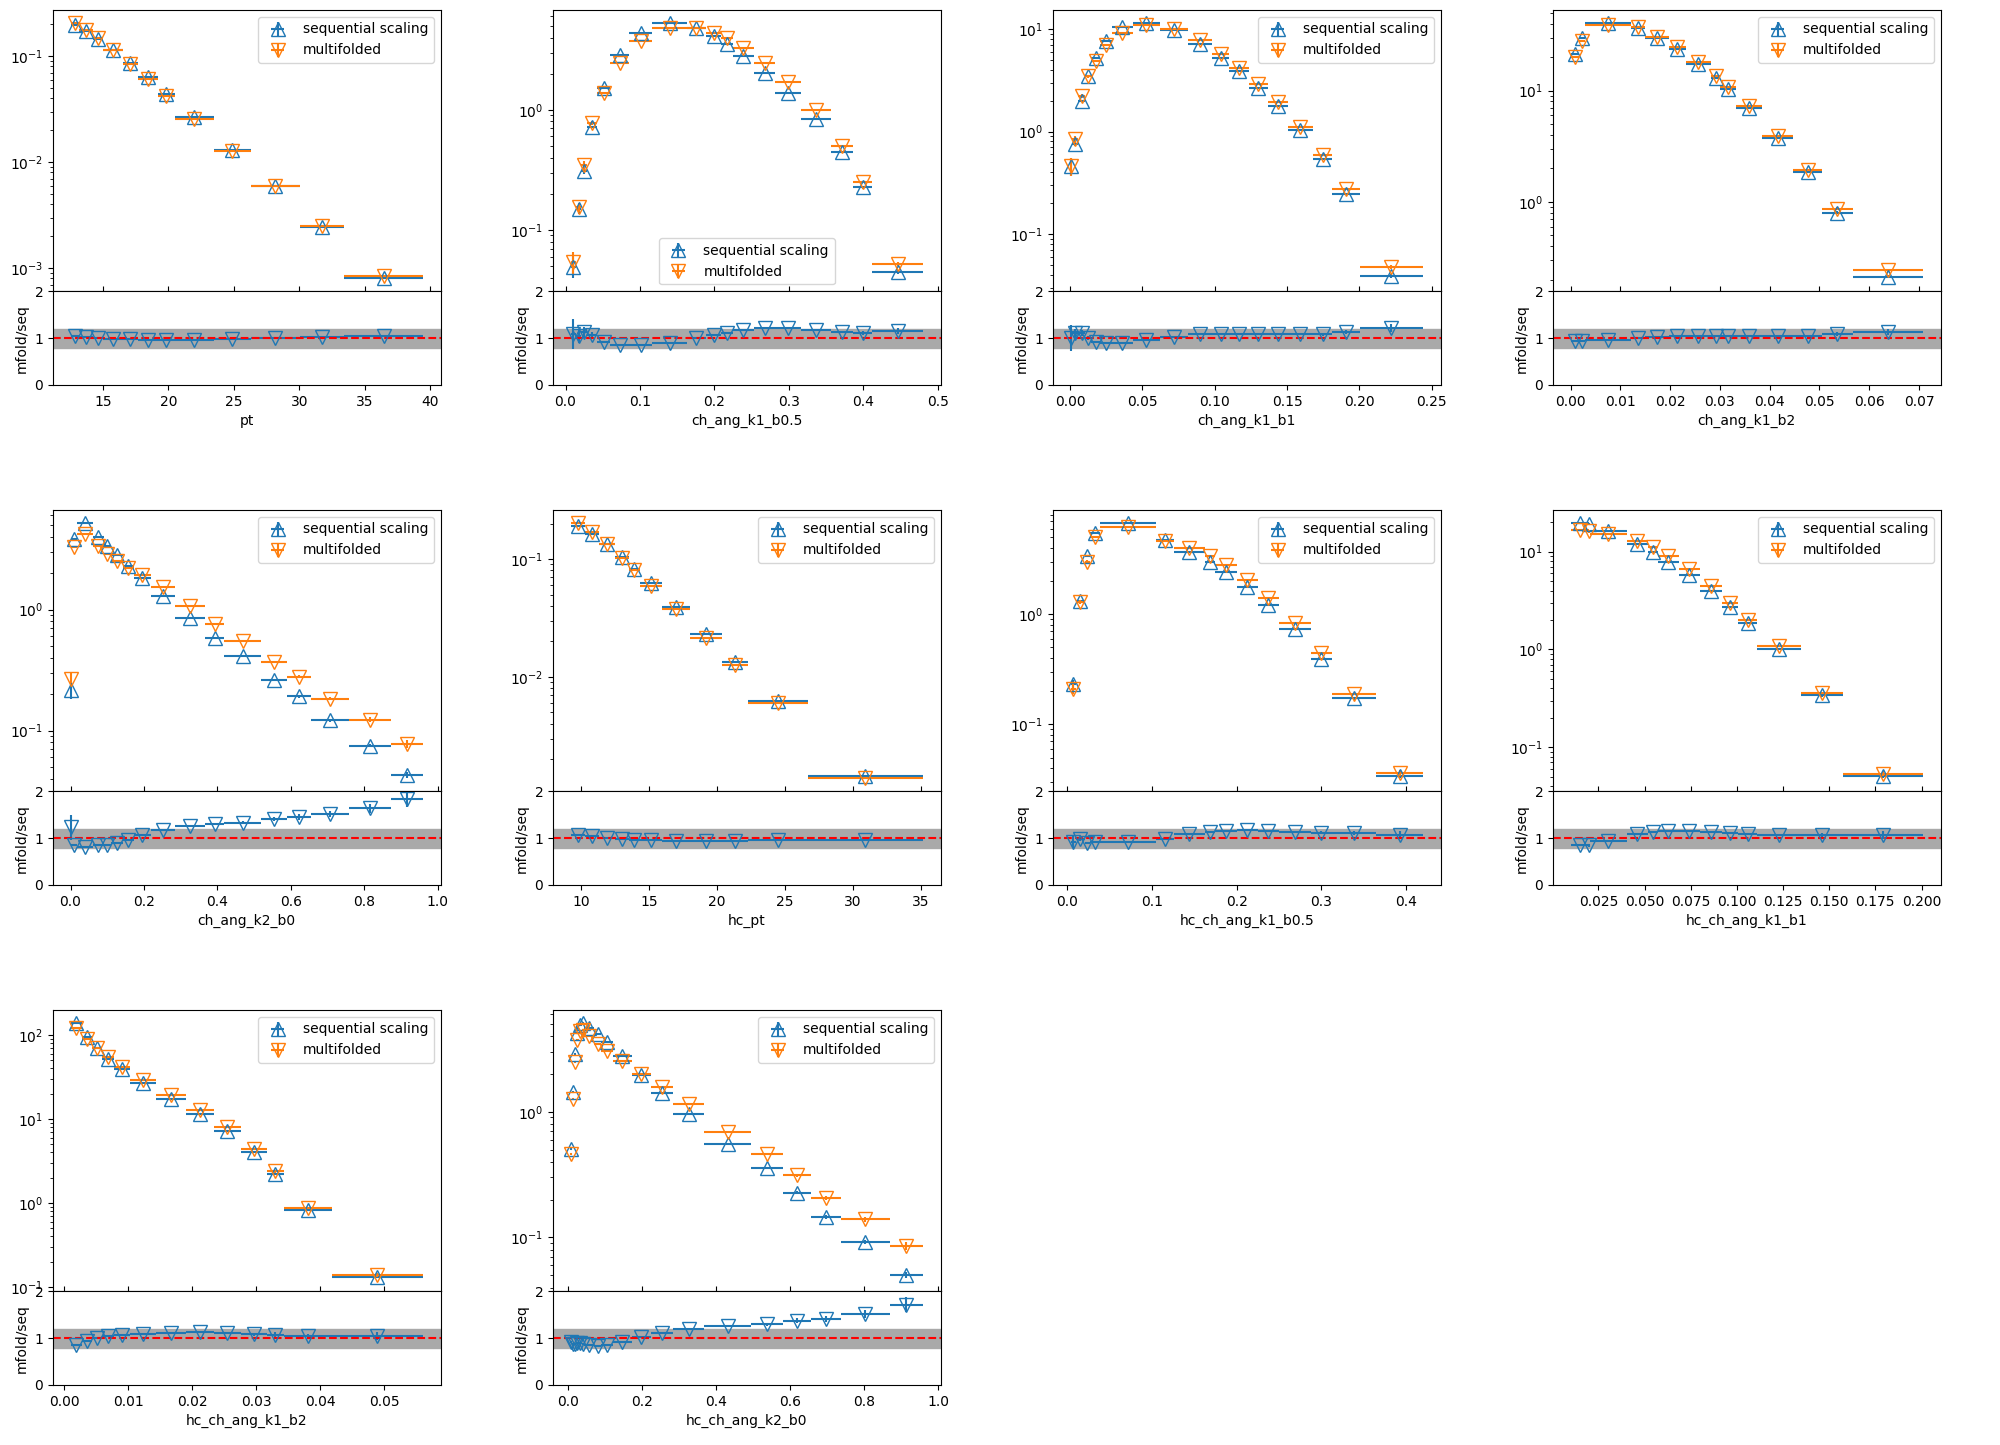

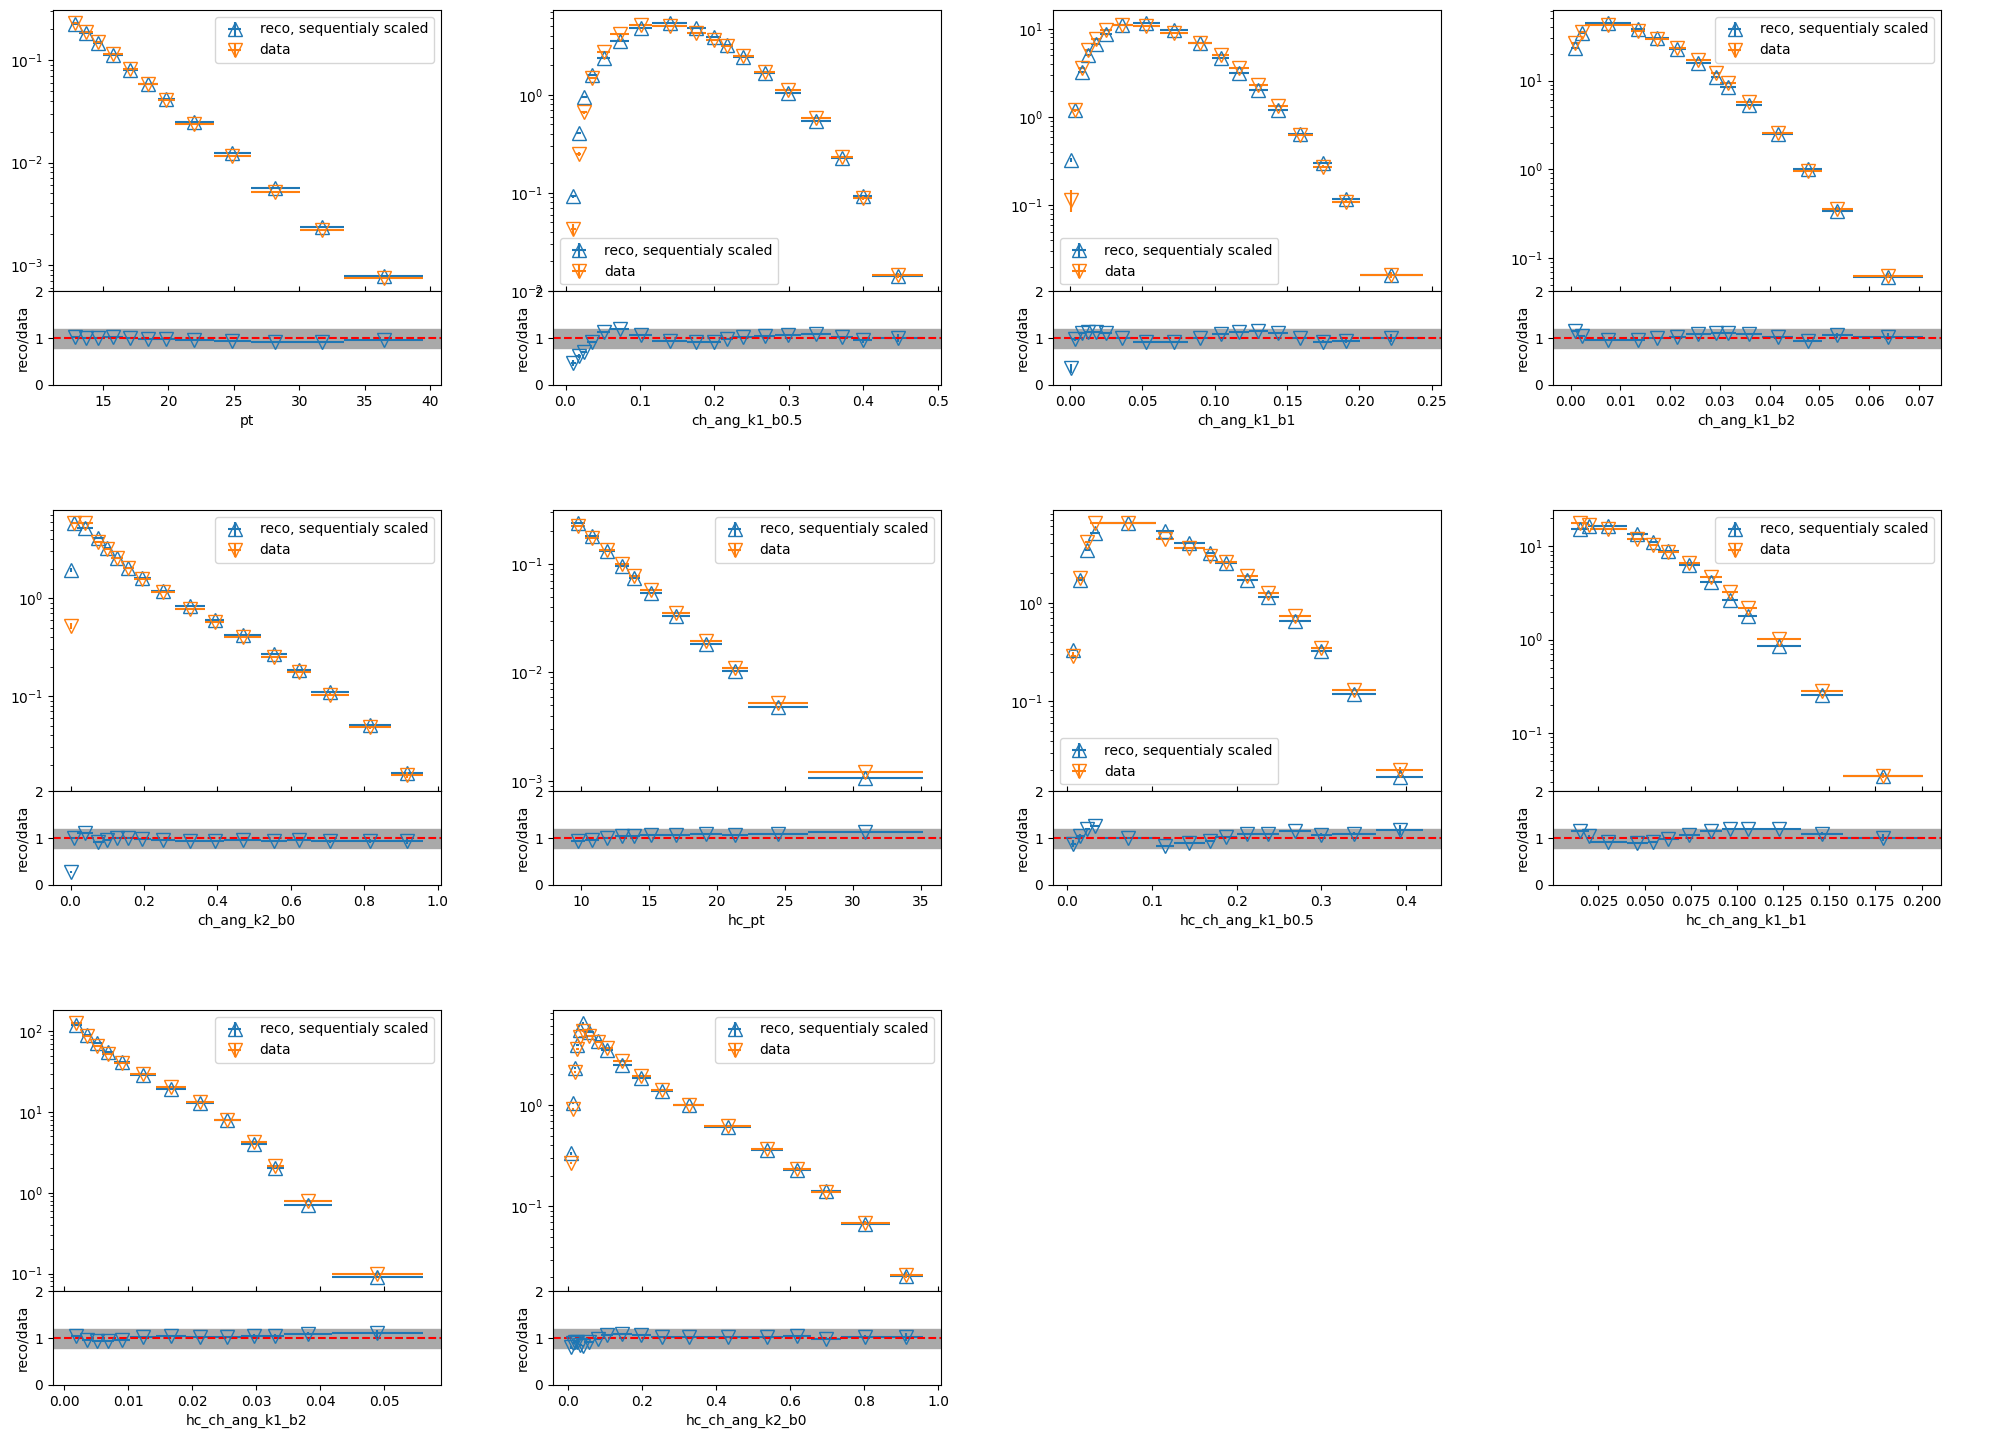

In [4]:
from matplotlib import pyplot as plt
from histograms import make_hist
from plotting import plot_ratios

plot_output_dir = "plot_output"
if not os.path.exists(plot_output_dir):
    os.makedirs(plot_output_dir)

jet_columns = [
     "pt",
     #"nef",
     "ch_ang_k1_b0.5",
     "ch_ang_k1_b1",
     "ch_ang_k1_b2",
     "ch_ang_k2_b0",
     #"leading_constit_pt",
     #"subleading_constit_pt",
     "hc_pt",
     "hc_ch_ang_k1_b0.5",
     "hc_ch_ang_k1_b1",
     "hc_ch_ang_k1_b2",
     "hc_ch_ang_k2_b0",
     ]

do_use_gen_misses = False
if do_use_gen_misses:
    gen_table = pa.concat_tables([gen_match_table, gen_miss_table])
    gen_stratify_label = np.concatenate([gen_match_stratify_label, gen_miss_stratify_label])
else:
    gen_table = gen_match_table
    gen_stratify_label = gen_match_stratify_label

reco_table =pa.concat_tables([reco_match_table, reco_fake_table])
reco_stratify_label = np.concatenate([reco_match_stratify_label, reco_fake_stratify_label])
 
mlt_wts = np.load(f"{emb_data_folder}/multifolding_1/multifolded-wts-iter5.npz")
imlt = 4

seq_wts = np.load(f"{emb_data_folder}/omnisequential_1/omniseq-wts-iter10.npz")
iseq = 9

col_bins = None
with open(f"{emb_data_folder}/omnisequential_1/omniseq-bins10.pkl", "rb") as f:
    col_bins = pickle.load(f)
    col_bins["ch_ang_k1_b2"] = col_bins["ch_ang_k1_b2"][1:]
    col_bins["pt"] = col_bins["pt"][3:]
    col_bins["hc_pt"] = col_bins["hc_pt"][4:]

fig_scale = 5
nrows = 3
ncols = int(np.ceil(len(jet_columns)/nrows))
fig_size = (ncols*fig_scale, nrows*fig_scale)

fig0 = plt.figure(figsize=fig_size)
subfigs0 = fig0.subfigures(nrows, ncols)
for ivar, var in enumerate(jet_columns):
    irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    
    _, h_mlt, h_mlt_err = make_hist(gen_table[var].to_numpy(), weight=mlt_wts[f"arr_{2*imlt}"], bins=bins)
    _, h_seq, h_seq_err = make_hist(gen_table[var].to_numpy(), weight=seq_wts[f"arr_{2*iseq}"], bins=bins)
    
    h_ratio = h_mlt / h_seq
    h_ratio_err = h_ratio * np.sqrt((h_mlt_err / h_mlt) ** 2 + (h_seq_err / h_seq) ** 2)
    
    axs = plot_ratios(subfigs0[irow, icol],
            bins,
            [h_seq],
            [h_mlt],
            [[h_ratio]],
            [h_seq_err],
            [h_mlt_err],
            [[h_ratio_err]],
            labels1=["sequential scaling"],
            labels2=["multifolded"],
            markers1=["^"],
            markers2=["v"])
    axs[1].set_xlabel(var)
    axs[1].set_ylabel("mfold/seq")
    axs[0].legend()
fig0.savefig(f"{plot_output_dir}/mfold_seq_ratio.pdf")
    

fig1 = plt.figure(figsize=fig_size)
subfigs1 = fig1.subfigures(nrows, ncols)
for ivar, var in enumerate(jet_columns):
    irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    
    _, h_data, h_data_err = make_hist(data_table[var].to_numpy(), bins=bins)
    _, h_reco, h_reco_err = make_hist(reco_table[var].to_numpy(), weight=seq_wts[f"arr_{2*iseq+1}"], bins=bins)
    
    h_ratio = h_reco / h_data
    h_ratio_err = h_ratio * np.sqrt((h_data_err / h_data) ** 2 + (h_reco_err / h_reco) ** 2)
    
    axs = plot_ratios(subfigs1[irow, icol],
            bins,
            [h_data],
            [h_reco],
            [[h_ratio]],
            [h_data_err],
            [h_reco_err],
            [[h_ratio_err]],
            labels1=["reco, sequentialy scaled"],
            labels2=["data"],
            markers1=["^"],
            markers2=["v"])
    axs[1].set_xlabel(var)
    axs[1].set_ylabel("reco/data")
    axs[0].legend()
fig1.savefig(f"{plot_output_dir}/data_reco_ratio.pdf")
    #print(len(gen_table), len(mlt_wts[f"arr_{2*imlt}"]), len(seq_wts[f"arr_{2*iseq}"]))
    
    #ax0[irow, icol].hist(gen_table[var].to_numpy(), weights=mlt_wts[f"arr_{2*imlt}"], density=True, bins=bins, label="multifolded", histtype="step")
    #ax0[irow, icol].hist(gen_table[var].to_numpy(), weights=seq_wts[f"arr_{2*iseq}"], density=True, bins=bins, label="omnisequential", histtype="step")
    #ax0[irow, icol].set_yscale("log")
    #ax0[irow, icol].legend()
     


/tmp/ipykernel_4644/2646769285.py:32: RuntimeWarning: invalid value encountered in divide
  h_ratio_err = h_ratio * np.sqrt((h_ang_err / h_ang) ** 2 + (h_hc_ang_err / h_hc_ang) ** 2)


/tmp/ipykernel_4644/2646769285.py:31: RuntimeWarning: invalid value encountered in divide
  h_ratio = h_hc_ang / h_ang


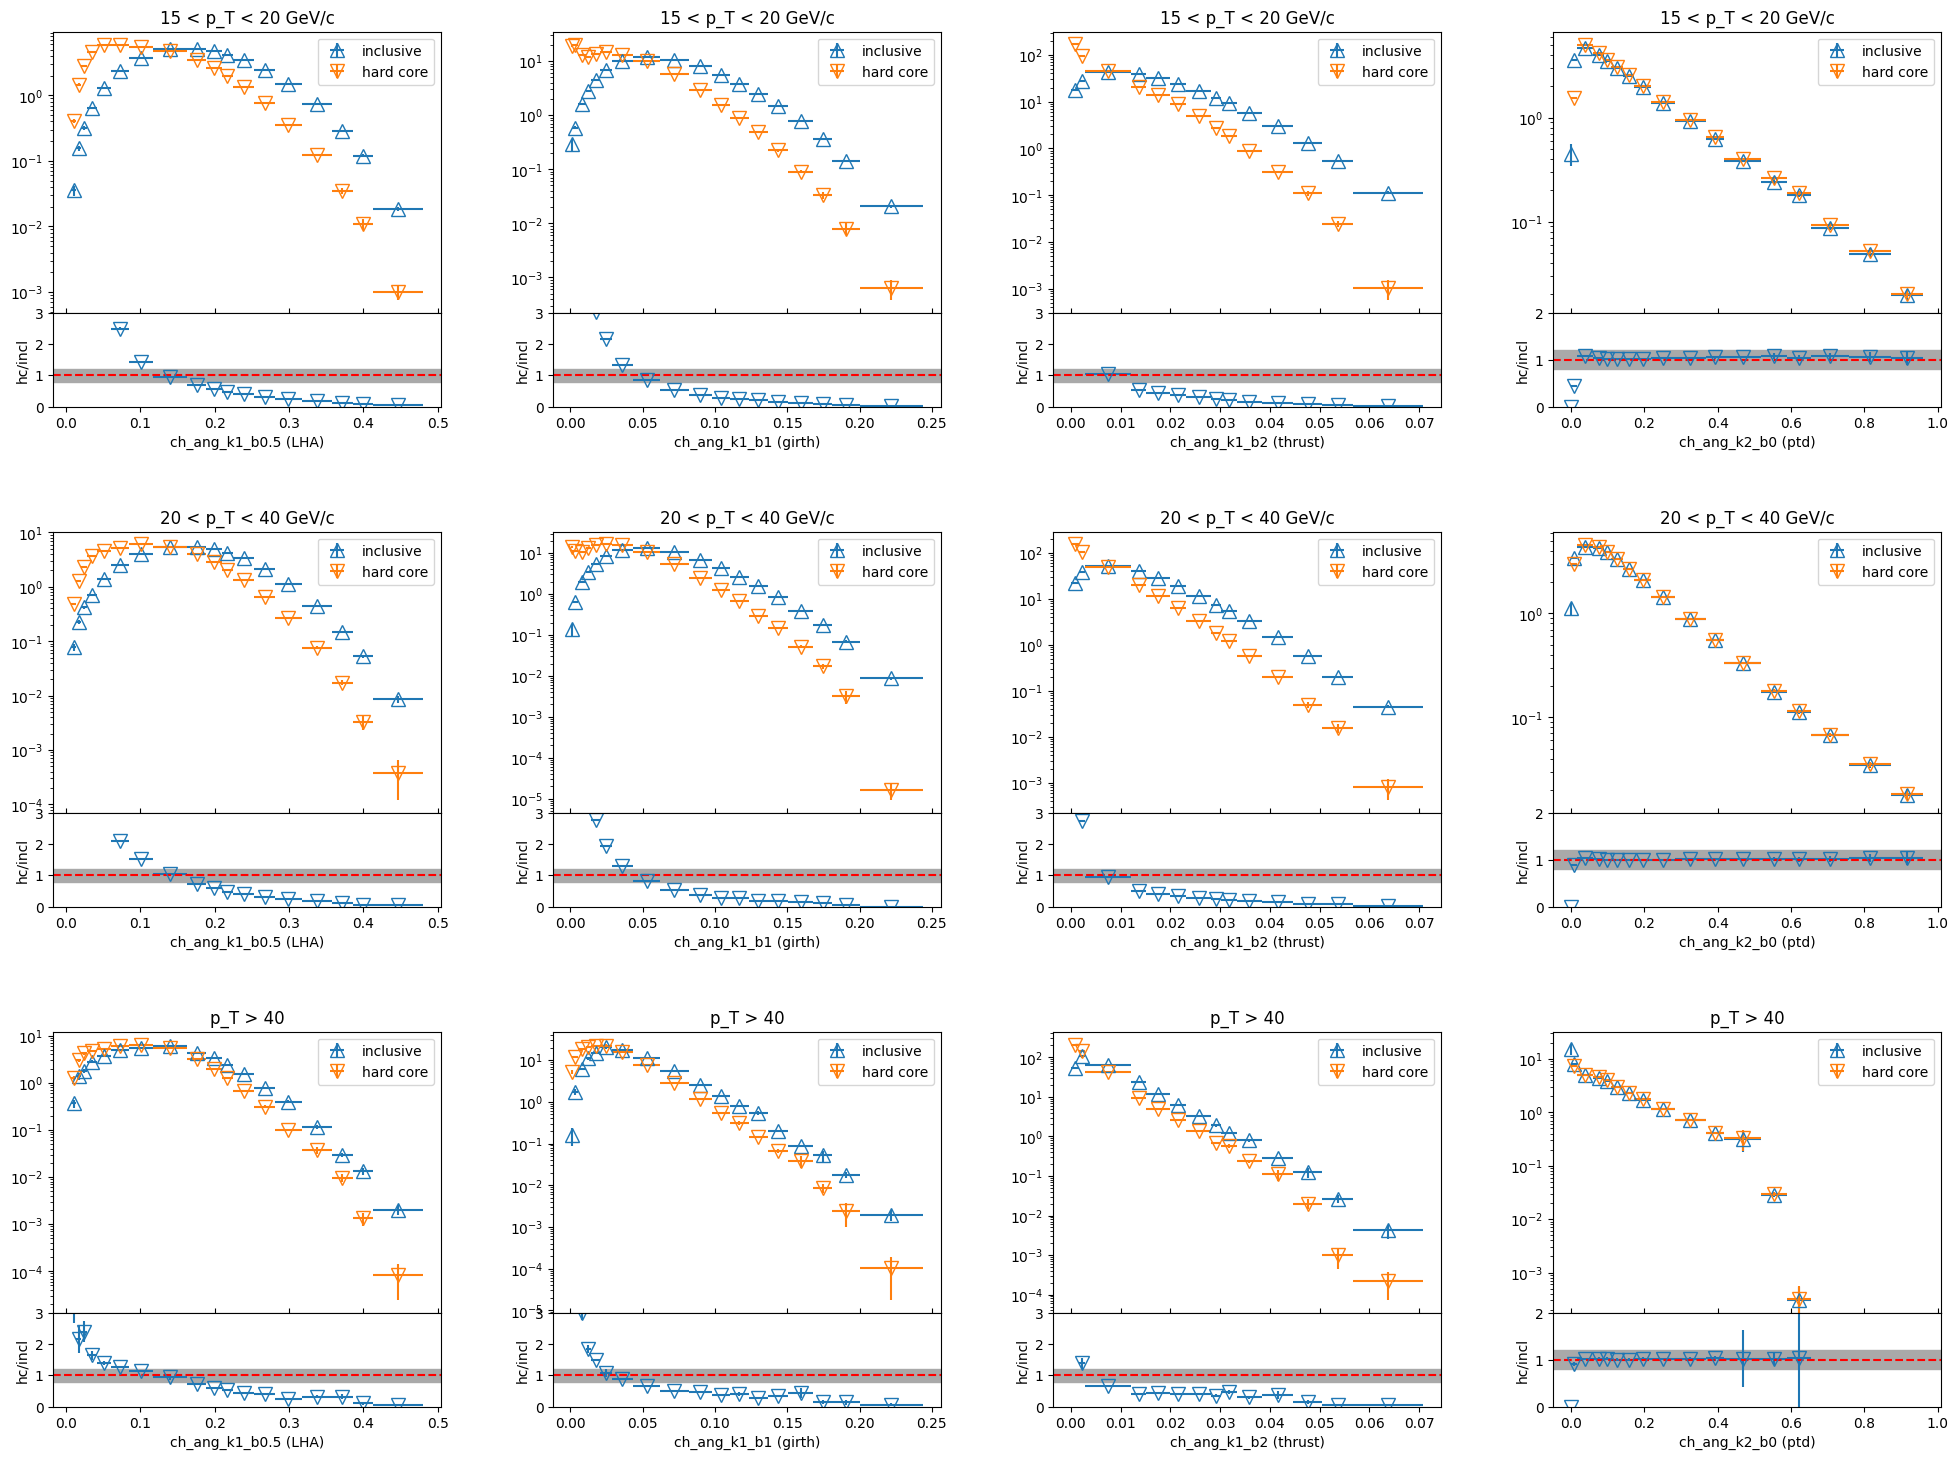

In [23]:
import math
ang_columns = [
     "ch_ang_k1_b0.5",
     "ch_ang_k1_b1",
     "ch_ang_k1_b2",
     "ch_ang_k2_b0",
     ]
     
ang_extra_labels = ["LHA", "girth", "thrust", "ptd"]

ratio_ylim = [[0, 3], [0, 3], [0,3], [0, 2]]

pt_arr = gen_table["pt"].to_numpy()
pt_bin_edges = [15, 20, 40, float("inf")]
pt_bin_masks = [(pt_arr > low)&(pt_arr < high) for low, high in zip(pt_bin_edges[:-1], pt_bin_edges[1:])]
pt_bin_labels =  [f"{low} < p_T < {high} GeV/c" if not math.isinf(high) else f"p_T > {low}" for low, high in zip(pt_bin_edges[:-1], pt_bin_edges[1:])]

fig_scale = 5
ncols = len(ang_columns)
nrows = len(pt_bin_labels)
fig = plt.figure(figsize=(fig_scale*ncols, nrows*fig_scale))
subfigs = fig.subfigures(nrows, ncols)
for ivar, var in enumerate(ang_columns):
    #irow = int(np.floor(ivar/ncols))
    icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else None
    axs = []
    for ipt_bin, pt_bin_mask in enumerate(pt_bin_masks):
        _, h_ang, h_ang_err = make_hist(gen_table[var].to_numpy()[pt_bin_mask], weight=mlt_wts[f"arr_{2*imlt}"][pt_bin_mask], bins=bins)
        _, h_hc_ang, h_hc_ang_err = make_hist(gen_table[f"hc_{var}"].to_numpy()[pt_bin_mask], weight=mlt_wts[f"arr_{2*imlt}"][pt_bin_mask], bins=bins)
        h_ratio = h_hc_ang / h_ang
        h_ratio_err = h_ratio * np.sqrt((h_ang_err / h_ang) ** 2 + (h_hc_ang_err / h_hc_ang) ** 2)

        axs.append(plot_ratios(
            subfigs[ipt_bin, icol], bins, 
            [h_ang], [h_hc_ang], [[h_ratio]],
            [h_ang_err], [h_hc_ang_err], [[h_ratio_err]],
            labels1=["inclusive"], markers1=["^"],
            labels2=["hard core"], markers2=["v"]
           ))
        axs[-1][1].set_xlabel(f"{var} ({ang_extra_labels[ivar]})")
        axs[-1][1].set_ylabel("hc/incl")
        axs[-1][0].set_title(pt_bin_labels[ipt_bin])
        axs[-1][1].set_ylim(*(ratio_ylim[ivar]))
        axs[-1][0].legend()
      
fig.savefig(f"{plot_output_dir}/incl_hcore_ratio.pdf")


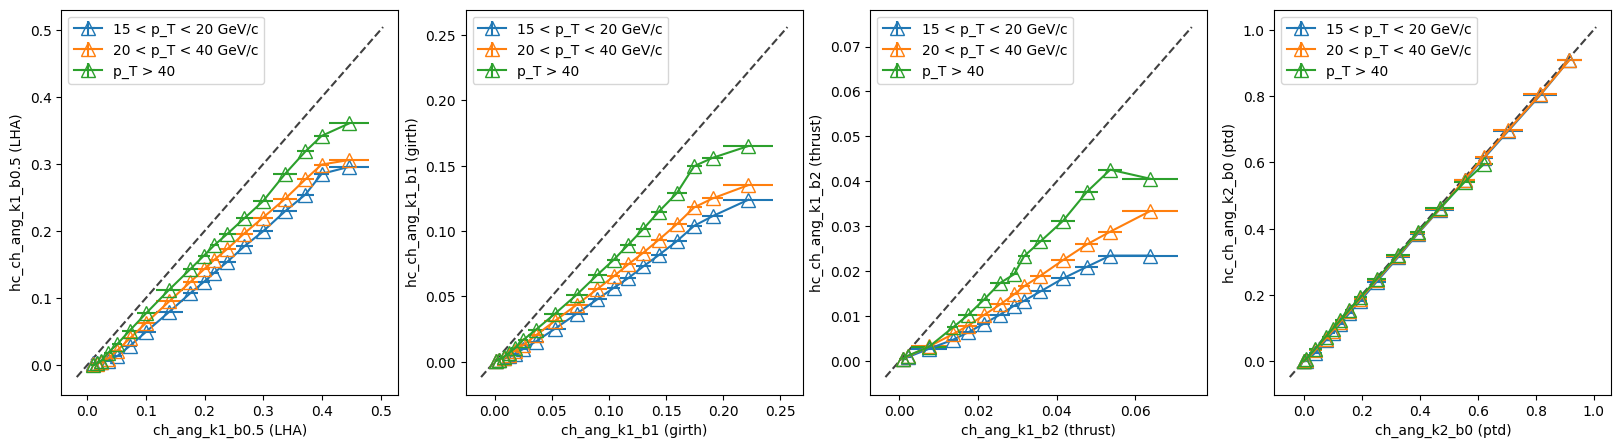

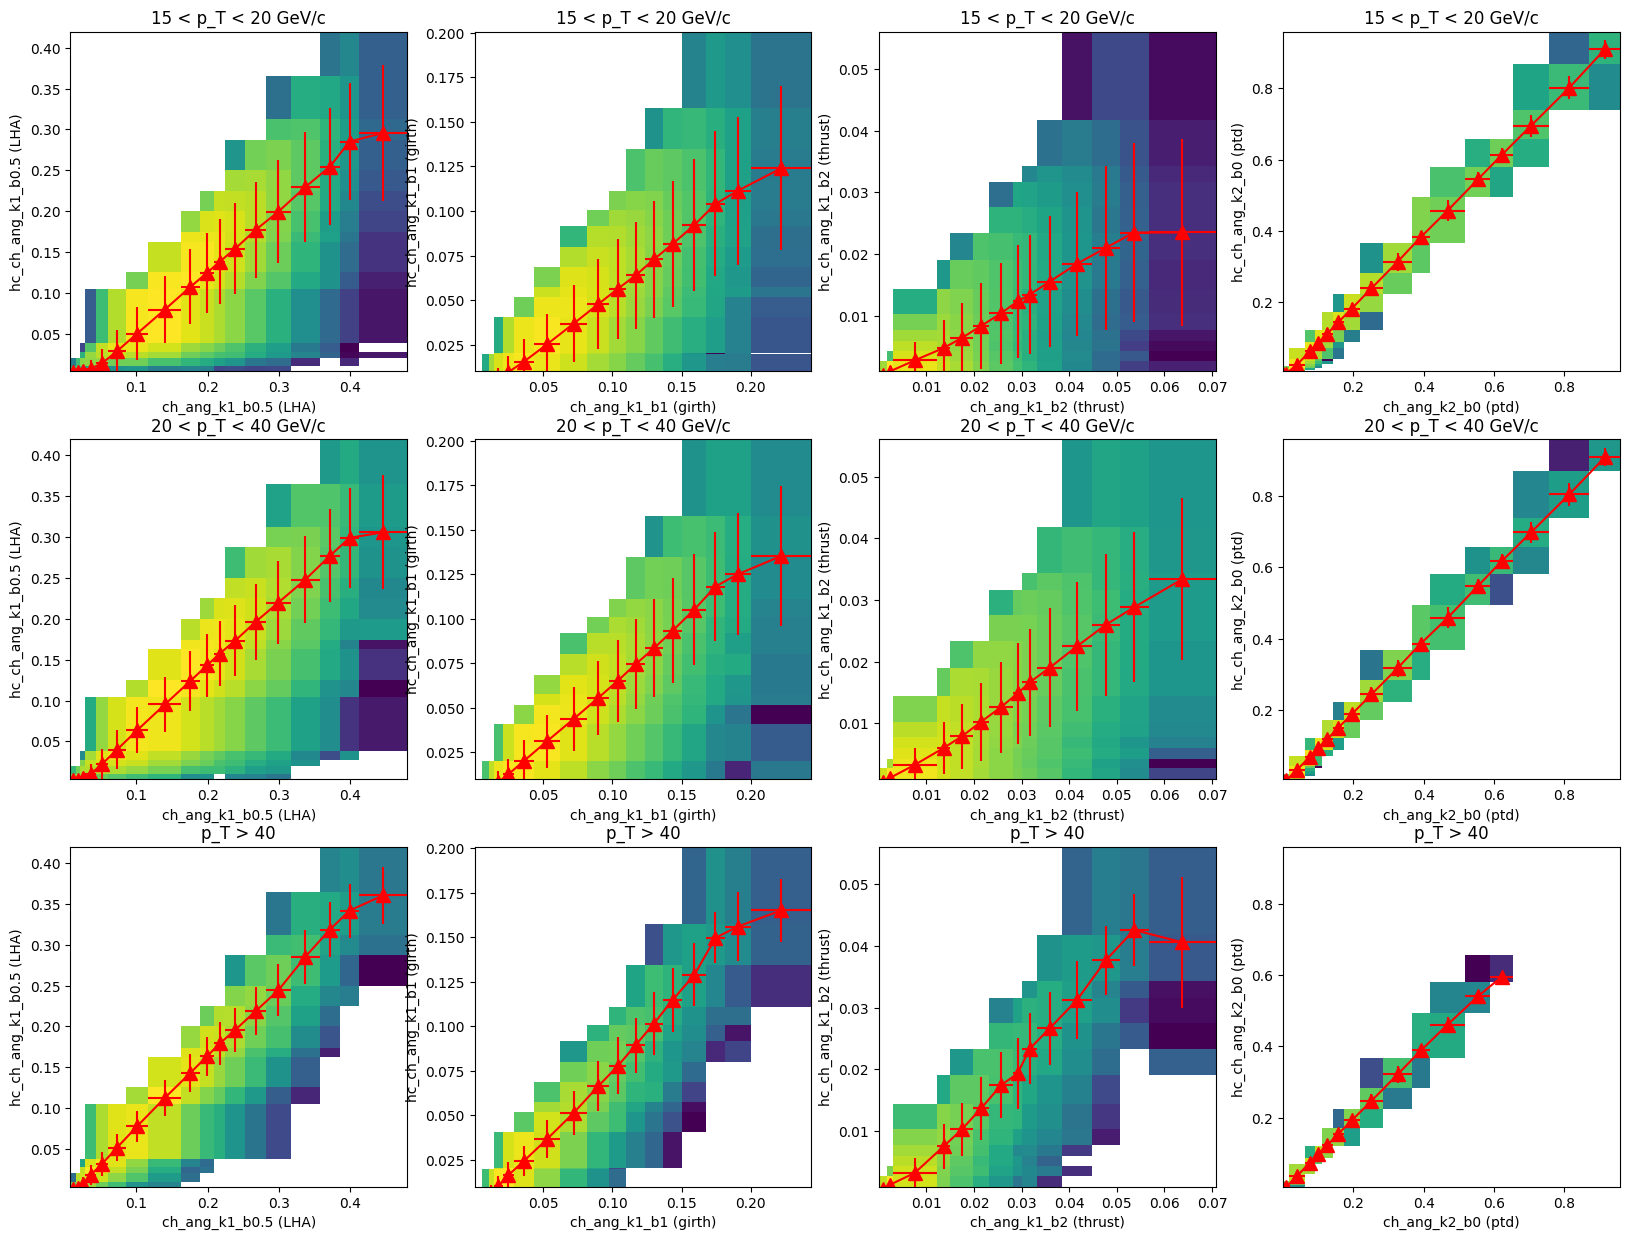

In [25]:
from histograms import make_profile

fig_scale = 5
ncols = len(ang_columns)
fig0, ax0s = plt.subplots(1, ncols, figsize=(fig_scale*ncols, fig_scale))
fig, axs = plt.subplots(nrows, ncols, figsize=(fig_scale*ncols, nrows*fig_scale))
for icol, var in enumerate(ang_columns):
    #irow = int(np.floor(ivar/ncols))
    #icol = ivar%ncols
    bins = col_bins[var] if col_bins is not None else 100
    hc_bins = col_bins[f"hc_{var}"] if col_bins is not None else 100
    
    wts = mlt_wts[f"arr_{2*imlt}"]
    arr = gen_table[var].to_numpy()
    hc_arr = gen_table[f"hc_{var}"].to_numpy()
    
    x = (bins[1:]+bins[:-1])/2.0
    x_err = (bins[1:]-bins[:-1])/2.0
    
    for ipt_bin, pt_bin_mask in enumerate(pt_bin_masks):
        _, prof, prof_err = make_profile(arr[pt_bin_mask], hc_arr[pt_bin_mask], weight=wts[pt_bin_mask], bins=bins)
        axs[ipt_bin, icol].hist2d(arr[pt_bin_mask], hc_arr[pt_bin_mask], weights=wts[pt_bin_mask], bins=[bins, hc_bins], density=True, norm="log")
        if ipt_bin == 2 and var == "ch_ang_k2_b0":
            ax0s[icol].errorbar(x[:-3], prof[:-3], xerr=x_err[:-3], yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            axs[ipt_bin, icol].errorbar(x[:-3], prof[:-3], xerr=x_err[:-3], yerr=prof_err[:-3], marker="^", markersize=10, color="red")
        else:
            ax0s[icol].errorbar(x, prof, xerr=x_err, yerr=0, marker="^", markersize=10, fillstyle="none", label=pt_bin_labels[ipt_bin])
            axs[ipt_bin, icol].errorbar(x, prof, xerr=x_err, yerr=prof_err, marker="^", markersize=10, color="red")
        axs[ipt_bin, icol].set_title(pt_bin_labels[ipt_bin])
        axs[ipt_bin, icol].set_xlabel(f"{var} ({ang_extra_labels[icol]})")
        axs[ipt_bin, icol].set_ylabel(f"hc_{var} ({ang_extra_labels[icol]})")

    lims = [np.min([ax0s[icol].get_xlim(), ax0s[icol].get_ylim()]),  np.max([ax0s[icol].get_xlim(), ax0s[icol].get_ylim()])]
    ax0s[icol].plot(lims, lims, 'k-', linestyle="--", alpha=0.75, zorder=0)
    ax0s[icol].set_xlabel(f"{var} ({ang_extra_labels[icol]})")
    ax0s[icol].set_ylabel(f"hc_{var} ({ang_extra_labels[icol]})")
    ax0s[icol].legend()

fig.savefig(f"{plot_output_dir}/incl_hcore_2d.pdf")
fig0.savefig(f"{plot_output_dir}/incl_hcore_profile.pdf")
